# Lizard Species Classification - Phase 3: Model Evaluation & Testing
## Thomas More - Artificial Intelligence Course

**Purpose**: Comprehensive model evaluation, error analysis, and test set predictions for Kaggle submission

**Input**: Trained model and metadata from previous notebooks

**Output**: Kaggle submission file and detailed performance analysis

## Section 1: Setup and Imports

In [26]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from PIL import Image
import warnings

warnings.filterwarnings('ignore')

# Deterministic mode
os.environ['TF_DETERMINISTIC_OPS'] = '1'

print(f"âœ“ TensorFlow version: {tf.__version__}")
print(f"âœ“ GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

âœ“ TensorFlow version: 2.21.0
âœ“ GPU available: False


## Section 2: Load Trained Model and Metadata

In [27]:
# Setup paths
BASE_DIR = Path(r'c:\Users\aarya\OneDrive\Desktop\school\thomasmore\year2\ai\lizardwizard')
TRAIN_DIR = BASE_DIR / 'train'
TEST_DIR = BASE_DIR / 'test'
METADATA_DIR = BASE_DIR / 'metadata'
MODELS_DIR = BASE_DIR / 'models'

# Create results directory
RESULTS_DIR = BASE_DIR / 'results'
RESULTS_DIR.mkdir(exist_ok=True)

print(f"Base directory: {BASE_DIR}")
print(f"Models directory: {MODELS_DIR}")
print(f"Results directory: {RESULTS_DIR}")

Base directory: c:\Users\aarya\OneDrive\Desktop\school\thomasmore\year2\ai\lizardwizard
Models directory: c:\Users\aarya\OneDrive\Desktop\school\thomasmore\year2\ai\lizardwizard\models
Results directory: c:\Users\aarya\OneDrive\Desktop\school\thomasmore\year2\ai\lizardwizard\results


In [28]:
# Load metadata
clean_train_df = pd.read_csv(METADATA_DIR / 'clean_train.csv')
clean_test_df = pd.read_csv(METADATA_DIR / 'clean_test.csv')

with open(METADATA_DIR / 'class_mappings.json', 'r') as f:
    class_mappings = json.load(f)

CLASS_TO_IDX = class_mappings['class_to_idx']
IDX_TO_CLASS = {int(k): v for k, v in class_mappings['idx_to_class'].items()}
NUM_CLASSES = class_mappings['num_classes']

with open(METADATA_DIR / 'eda_config.json', 'r') as f:
    eda_config = json.load(f)

with open(MODELS_DIR / 'training_results.json', 'r') as f:
    training_results = json.load(f)

IMAGE_SIZE = training_results['config']['image_size']
BATCH_SIZE = training_results['config']['batch_size']

print(f"âœ“ Loaded {len(clean_train_df)} training samples")
print(f"âœ“ Loaded {len(clean_test_df)} test samples")
print(f"âœ“ Loaded {NUM_CLASSES} classes")
print(f"âœ“ Image size: {IMAGE_SIZE}x{IMAGE_SIZE}")

âœ“ Loaded 1334 training samples
âœ“ Loaded 326 test samples
âœ“ Loaded 7 classes
âœ“ Image size: 224x224


In [29]:
# Load trained model
print("Loading trained model...")
model = keras.models.load_model(str(MODELS_DIR / 'final_model.h5'))
print(f"âœ“ Model loaded successfully")
print(f"\nModel summary:")
model.summary()

Loading trained model...


âœ“ Model loaded successfully

Model summary:


Model: "LizardClassifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb2 (Functional)     │ (None, 7, 7, 1408)     │     7,768,569 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1408)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       721,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,626,178 (32.91 MB)

 Trainable params: 7,614,941 (29.05 MB)

 Non-trainable params: 1,011,235 (3.86 MB)

 Optimizer params: 2 (12.00 B)

In [30]:
# Path resolution utilities (same as training notebook)
def normalize_class_name(name):
    return name.replace('-', '_')

def resolve_image_path(filename, class_idx):
    csv_class_name = list(CLASS_TO_IDX.keys())[class_idx]
    folder_class_name = normalize_class_name(csv_class_name)
    class_folder = TRAIN_DIR / folder_class_name
    image_path = class_folder / filename
    return image_path

def load_image(image_path, image_size=224):
    try:
        img = keras.preprocessing.image.load_img(str(image_path), target_size=(image_size, image_size))
        img_array = keras.preprocessing.image.img_to_array(img)
        img_array = img_array / 255.0
        return img_array.astype(np.float32)
    except Exception as e:
        print(f"Error loading {image_path}: {e}")
        return np.zeros((image_size, image_size, 3), dtype=np.float32)

print("âœ“ Path resolution and loading functions defined")

âœ“ Path resolution and loading functions defined


In [31]:
# Reconstruct train/validation split (same as training)
from sklearn.model_selection import train_test_split

SEED = 42
val_split = training_results['config']['validation_split']

train_indices, val_indices = train_test_split(
    np.arange(len(clean_train_df)),
    test_size=val_split,
    stratify=clean_train_df['label'].values,
    random_state=SEED
)

train_df_split = clean_train_df.iloc[train_indices].reset_index(drop=True)
val_df_split = clean_train_df.iloc[val_indices].reset_index(drop=True)

print(f"âœ“ Reconstructed splits:")
print(f"  Train: {len(train_df_split)} samples")
print(f"  Validation: {len(val_df_split)} samples")

âœ“ Reconstructed splits:
  Train: 1133 samples
  Validation: 201 samples


In [32]:
# Create validation dataset for evaluation
def create_eval_dataset(dataframe, batch_size, image_size=224):
    """Create dataset for evaluation (no augmentation)."""
    
    def load_image_label(row_index):
        row = dataframe.iloc[int(row_index.numpy())]
        img_path = resolve_image_path(row['id'], row['label'])
        img = load_image(img_path, image_size)
        label = tf.cast(row['label'], tf.int32)
        return img, label
    
    dataset = tf.data.Dataset.from_tensor_slices(np.arange(len(dataframe)))
    dataset = dataset.map(
        lambda idx: tf.py_function(load_image_label, [idx], (tf.float32, tf.int32)),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    
    return dataset

val_dataset = create_eval_dataset(val_df_split, BATCH_SIZE, IMAGE_SIZE)
print(f"✓ Validation dataset created")

✓ Validation dataset created


## Section 3: Generate Predictions on Validation Set

In [33]:
print("Generating predictions on validation set...\n")

y_true = []
y_pred = []
y_pred_proba = []

for images, labels in val_dataset:
    predictions = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(predictions, axis=1))
    y_pred_proba.extend(np.max(predictions, axis=1))  # Confidence scores
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_pred_proba = np.array(y_pred_proba)

print(f"âœ“ Generated {len(y_pred)} predictions")
print(f"Prediction confidence - min: {y_pred_proba.min():.4f}, max: {y_pred_proba.max():.4f}, mean: {y_pred_proba.mean():.4f}")

Generating predictions on validation set...

âœ“ Generated 201 predictions
Prediction confidence - min: 0.2708, max: 0.2743, mean: 0.2731


## Section 4: Performance Metrics

In [34]:
# Overall accuracy
val_accuracy = accuracy_score(y_true, y_pred)
print(f"\n{'='*80}")
print(f"VALIDATION SET PERFORMANCE")
print(f"{'='*80}")
print(f"\nOverall Accuracy: {val_accuracy:.4f} ({100*val_accuracy:.2f}%)")

# Per-class accuracy
print(f"\nPer-Class Accuracy:")
print(f"{'Class':<40} {'Accuracy':>10} {'Samples':>10}")
print(f"{'-'*60}")
for idx in range(NUM_CLASSES):
    class_mask = y_true == idx
    if class_mask.sum() > 0:
        class_acc = accuracy_score(y_true[class_mask], y_pred[class_mask])
        class_name = IDX_TO_CLASS[idx]
        print(f"{class_name:<40} {class_acc:>10.4f} {class_mask.sum():>10}")


VALIDATION SET PERFORMANCE

Overall Accuracy: 0.1443 (14.43%)

Per-Class Accuracy:
Class                                      Accuracy    Samples
------------------------------------------------------------
Black_spiny_tailed_iguana                    0.0000         30
Brown_anole                                  1.0000         29
Cuban_knight_anole                           0.0000         28
Desert_iguana                                0.0000         28
Green_anole                                  0.0000         27
Green_iguana                                 0.0000         30
Lesser_Antillean_iguana                      0.0000         29


In [35]:
# Classification report
class_names = [IDX_TO_CLASS[i] for i in range(NUM_CLASSES)]
print(f"\nDetailed Classification Report:")
print(f"{'='*80}")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))


Detailed Classification Report:
                           precision    recall  f1-score   support

Black_spiny_tailed_iguana     0.0000    0.0000    0.0000        30
              Brown_anole     0.1443    1.0000    0.2522        29
       Cuban_knight_anole     0.0000    0.0000    0.0000        28
            Desert_iguana     0.0000    0.0000    0.0000        28
              Green_anole     0.0000    0.0000    0.0000        27
             Green_iguana     0.0000    0.0000    0.0000        30
  Lesser_Antillean_iguana     0.0000    0.0000    0.0000        29

                 accuracy                         0.1443       201
                macro avg     0.0206    0.1429    0.0360       201
             weighted avg     0.0208    0.1443    0.0364       201



## Section 5: Confusion Matrix Analysis

In [36]:
# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)
print(f"\nConfusion Matrix (raw counts):")
print(cm)

# Normalize for visualization
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


Confusion Matrix (raw counts):
[[ 0 30  0  0  0  0  0]
 [ 0 29  0  0  0  0  0]
 [ 0 28  0  0  0  0  0]
 [ 0 28  0  0  0  0  0]
 [ 0 27  0  0  0  0  0]
 [ 0 30  0  0  0  0  0]
 [ 0 29  0  0  0  0  0]]


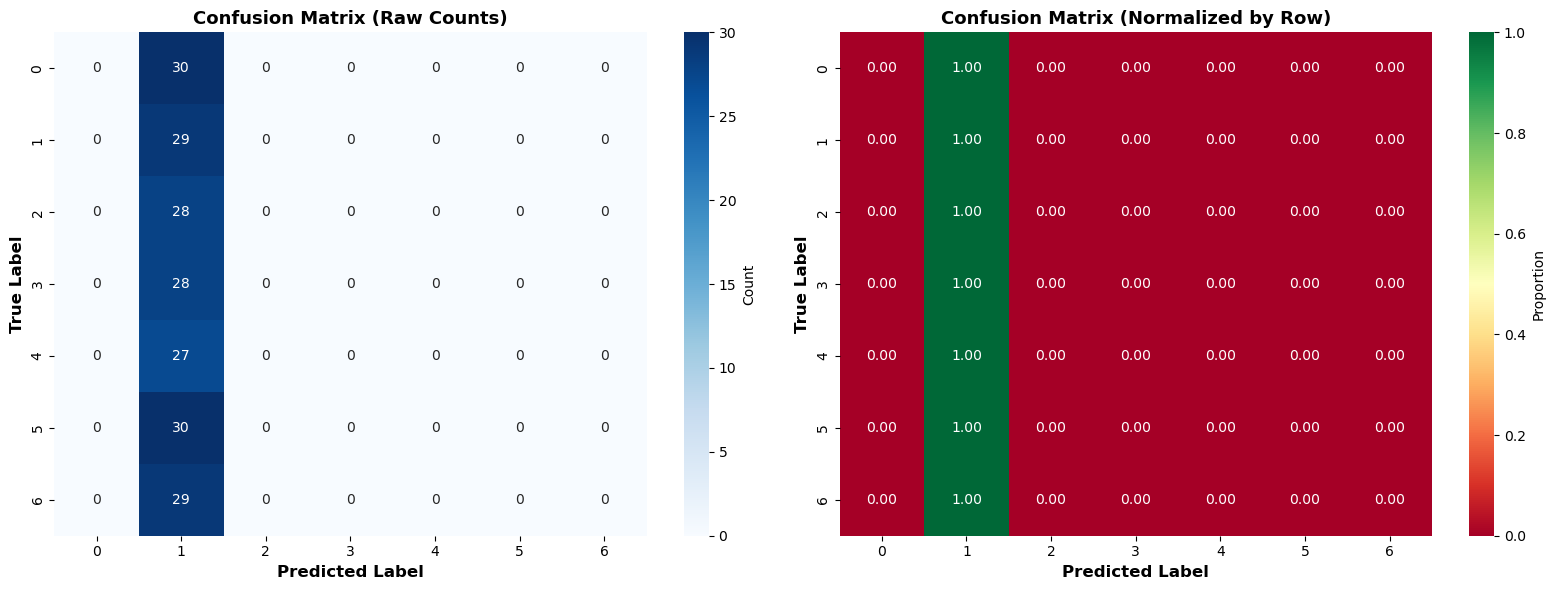

âœ“ Confusion matrix visualization saved


In [37]:
# Visualize confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
ax = axes[0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=True,
            xticklabels=range(NUM_CLASSES), yticklabels=range(NUM_CLASSES),
            cbar_kws={'label': 'Count'})
ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix (Raw Counts)', fontsize=13, fontweight='bold')

# Normalized
ax = axes[1]
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='RdYlGn', ax=ax, cbar=True,
            xticklabels=range(NUM_CLASSES), yticklabels=range(NUM_CLASSES),
            cbar_kws={'label': 'Proportion'})
ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix (Normalized by Row)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("âœ“ Confusion matrix visualization saved")

## Section 6: Error Analysis

In [38]:
# Top misclassification pairs
print(f"\n{'='*80}")
print(f"TOP MISCLASSIFICATION PATTERNS")
print(f"{'='*80}")

misclassifications = []
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if i != j:
            count = cm[i, j]
            if count > 0:
                percentage = 100 * count / cm[i].sum() if cm[i].sum() > 0 else 0
                misclassifications.append((i, j, count, percentage))

misclassifications.sort(key=lambda x: x[2], reverse=True)

print(f"\nTop 15 Confusion Pairs:")
print(f"{'Rank':<5} {'True Class':<35} {'Pred Class':<35} {'Count':>6} {'Pct':>6}")
print(f"{'-'*90}")
for idx, (true_label, pred_label, count, pct) in enumerate(misclassifications[:15]):
    true_name = IDX_TO_CLASS[true_label]
    pred_name = IDX_TO_CLASS[pred_label]
    print(f"{idx+1:<5} {true_name:<35} {pred_name:<35} {count:>6d} {pct:>5.1f}%")


TOP MISCLASSIFICATION PATTERNS

Top 15 Confusion Pairs:
Rank  True Class                          Pred Class                           Count    Pct
------------------------------------------------------------------------------------------
1     Black_spiny_tailed_iguana           Brown_anole                             30 100.0%
2     Green_iguana                        Brown_anole                             30 100.0%
3     Lesser_Antillean_iguana             Brown_anole                             29 100.0%
4     Cuban_knight_anole                  Brown_anole                             28 100.0%
5     Desert_iguana                       Brown_anole                             28 100.0%
6     Green_anole                         Brown_anole                             27 100.0%


In [39]:
# Misclassified samples
print(f"\n{'='*80}")
print(f"ERROR ANALYSIS: MISCLASSIFIED VALIDATION SAMPLES")
print(f"{'='*80}")

misclassified_indices = np.where(y_true != y_pred)[0]
print(f"\nTotal misclassified samples: {len(misclassified_indices)}/{len(y_true)} ({100*len(misclassified_indices)/len(y_true):.2f}%)")
print(f"Confidence scores for misclassified samples:")
print(f"  Min: {y_pred_proba[misclassified_indices].min():.4f}")
print(f"  Max: {y_pred_proba[misclassified_indices].max():.4f}")
print(f"  Mean: {y_pred_proba[misclassified_indices].mean():.4f}")
print(f"  Std: {y_pred_proba[misclassified_indices].std():.4f}")

print(f"\nConfidence scores for correctly classified samples:")
correct_indices = np.where(y_true == y_pred)[0]
print(f"  Min: {y_pred_proba[correct_indices].min():.4f}")
print(f"  Max: {y_pred_proba[correct_indices].max():.4f}")
print(f"  Mean: {y_pred_proba[correct_indices].mean():.4f}")
print(f"  Std: {y_pred_proba[correct_indices].std():.4f}")


ERROR ANALYSIS: MISCLASSIFIED VALIDATION SAMPLES

Total misclassified samples: 172/201 (85.57%)
Confidence scores for misclassified samples:
  Min: 0.2708
  Max: 0.2742
  Mean: 0.2730
  Std: 0.0008

Confidence scores for correctly classified samples:
  Min: 0.2713
  Max: 0.2743
  Mean: 0.2731
  Std: 0.0007



Visualizing misclassified validation examples...


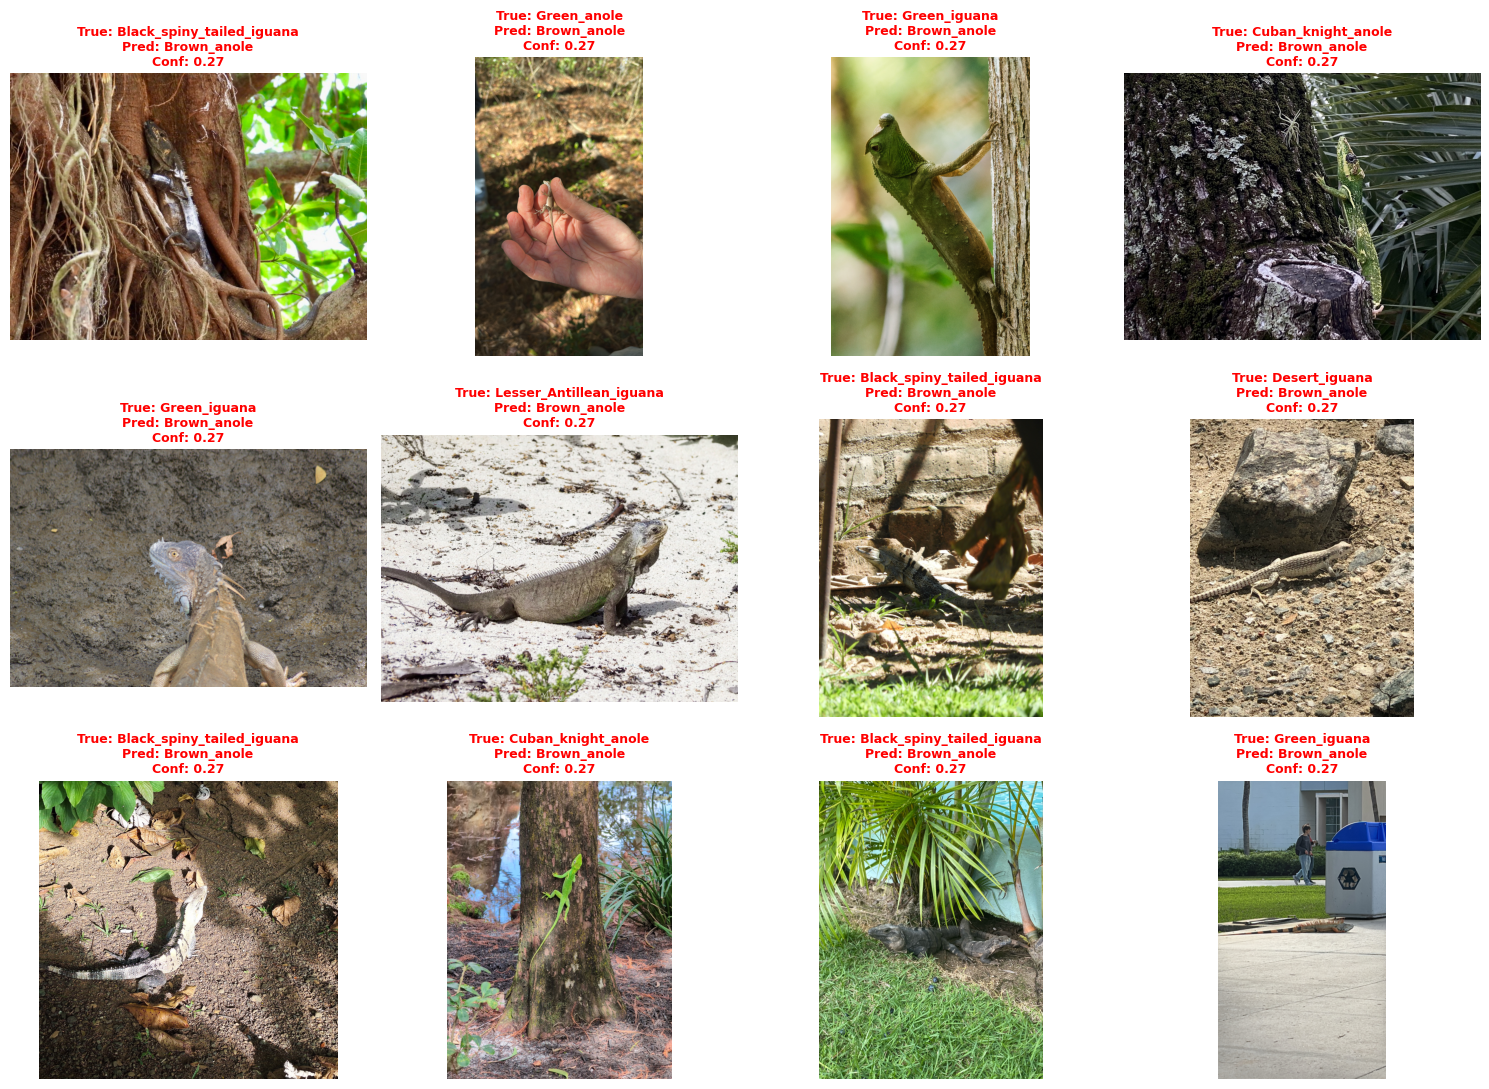

âœ“ Misclassified examples visualization saved


In [40]:
# Visualize misclassified examples
if len(misclassified_indices) > 0:
    print(f"\nVisualizing misclassified validation examples...")
    
    # Sample up to 12 misclassified examples
    sample_count = min(12, len(misclassified_indices))
    np.random.seed(42)
    sample_indices = np.random.choice(misclassified_indices, sample_count, replace=False)
    
    fig, axes = plt.subplots(3, 4, figsize=(15, 11))
    axes = axes.flatten()
    
    for plot_idx, val_idx in enumerate(sample_indices):
        # Find corresponding original sample
        original_idx = val_indices[val_idx]
        row = clean_train_df.iloc[original_idx]
        img_path = resolve_image_path(row['id'], row['label'])
        
        try:
            img = Image.open(str(img_path))
            axes[plot_idx].imshow(img)
            true_label = y_true[val_idx]
            pred_label = y_pred[val_idx]
            conf = y_pred_proba[val_idx]
            axes[plot_idx].set_title(
                f"True: {IDX_TO_CLASS[true_label]}\nPred: {IDX_TO_CLASS[pred_label]}\nConf: {conf:.2f}",
                fontsize=9, fontweight='bold', color='red'
            )
            axes[plot_idx].axis('off')
        except Exception as e:
            axes[plot_idx].text(0.5, 0.5, f"Error: {e}", ha='center', va='center', fontsize=8)
            axes[plot_idx].axis('off')
    
    # Hide extra subplots
    for idx in range(sample_count, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'misclassified_examples.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"âœ“ Misclassified examples visualization saved")
else:
    print("No misclassified examples found!")

## Section 7: Test Set Prediction and Kaggle Submission

In [41]:
print(f"\n{'='*80}")
print(f"TEST SET PREDICTION FOR KAGGLE SUBMISSION")
print(f"{'='*80}")

# Create test dataset
def create_test_dataset(test_df, batch_size, image_size=224):
    """Create dataset for test predictions."""
    
    def load_test_image(row_index):
        test_id = test_df.iloc[row_index]['id']
        img_path = TEST_DIR / test_id
        img = load_image(img_path, image_size)
        return img
    
    dataset = tf.data.Dataset.from_tensor_slices(np.arange(len(test_df)))
    dataset = dataset.map(
        lambda idx: tf.py_function(load_test_image, [idx], tf.float32),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    
    return dataset

test_dataset = create_test_dataset(clean_test_df, BATCH_SIZE, IMAGE_SIZE)
print(f"âœ“ Test dataset created: {len(clean_test_df)} images")


TEST SET PREDICTION FOR KAGGLE SUBMISSION
âœ“ Test dataset created: 326 images


In [ ]:
# Create test dataset (no labels needed)
def create_test_dataset(test_df, batch_size, image_size=224):
    """Create dataset for test data (no labels)."""
    
    def load_test_image(row_index):
        row = test_df.iloc[int(row_index.numpy())]
        img_path = TEST_DIR / f"{row['id']}.jpg"
        img = load_image(img_path, image_size)
        return img
    
    dataset = tf.data.Dataset.from_tensor_slices(np.arange(len(test_df)))
    dataset = dataset.map(
        lambda idx: tf.py_function(load_test_image, [idx], tf.float32),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    
    # Set explicit shape
    def set_shape(x):
        x.set_shape((IMAGE_SIZE, IMAGE_SIZE, 3))
        return x
    
    dataset = dataset.map(set_shape)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    
    return dataset

test_dataset = create_test_dataset(clean_test_df, BATCH_SIZE, IMAGE_SIZE)
print(f"✓ Test dataset created with {len(clean_test_df)} images")

# Generate test predictions
print("\nGenerating predictions on test set...")
test_predictions = []
test_confidences = []

for images in test_dataset:
    batch_predictions = model.predict(images, verbose=0)
    test_predictions.extend(np.argmax(batch_predictions, axis=1))
    test_confidences.extend(np.max(batch_predictions, axis=1))

test_predictions = np.array(test_predictions)
test_confidences = np.array(test_confidences)

print(f"✓ Generated {len(test_predictions)} test predictions")
print(f"\nPrediction statistics:")
print(f"  Prediction range: {test_predictions.min()} to {test_predictions.max()}")
print(f"  Confidence range: {test_confidences.min():.4f} to {test_confidences.max():.4f}")
print(f"  Mean confidence: {test_confidences.mean():.4f}")

print(f"\nTest prediction distribution:")
for idx in range(NUM_CLASSES):
    count = (test_predictions == idx).sum()
    pct = 100 * count / len(test_predictions)
    class_name = IDX_TO_CLASS[idx]
    print(f"  Class {idx} ({class_name:<30}): {count:3d} ({pct:5.1f}%)")


Generating predictions on test set...


InvalidArgumentError: {{function_node __wrapped__IteratorGetNext_output_types_1_device_/job:localhost/replica:0/task:0/device:CPU:0}} Error in user-defined function passed to MapDataset:200 transformation with iterator: Iterator::Root::Prefetch::BatchV2::Map: TypeError: Cannot index by location index with a non-integer key
Traceback (most recent call last):

  File "c:\Users\aarya\anaconda3\Lib\site-packages\tensorflow\python\ops\script_ops.py", line 267, in __call__
    return func(device, token, args)

  File "c:\Users\aarya\anaconda3\Lib\site-packages\tensorflow\python\ops\script_ops.py", line 145, in __call__
    outputs = self._call(device, args)

  File "c:\Users\aarya\anaconda3\Lib\site-packages\tensorflow\python\ops\script_ops.py", line 152, in _call
    ret = self._func(*args)

  File "c:\Users\aarya\anaconda3\Lib\site-packages\tensorflow\python\autograph\impl\api.py", line 643, in wrapper
    return func(*args, **kwargs)

  File "C:\Users\aarya\AppData\Local\Temp\ipykernel_24

## Section 8: Create Submission File

In [ ]:
# Create submission dataframe
submission_df = pd.DataFrame({
    'id': clean_test_df['id'].values,
    'label': test_predictions
})

# Verify submission format
print(f"\nSubmission File Validation:")
print(f"  Shape: {submission_df.shape}")
print(f"  Columns: {submission_df.columns.tolist()}")
print(f"  Label dtype: {submission_df['label'].dtype}")
print(f"  Label range: [{submission_df['label'].min()}, {submission_df['label'].max()}]")
print(f"  All labels valid (0-6): {submission_df['label'].min() >= 0 and submission_df['label'].max() <= 6}")
print(f"  No NaN values: {not submission_df.isnull().any().any()}")

print(f"\nSubmission preview (first 20 rows):")
print(submission_df.head(20))

In [ ]:
# Save submission
submission_path = RESULTS_DIR / 'submission.csv'
submission_df.to_csv(submission_path, index=False)

# Also save to main directory for convenience
submission_path_main = BASE_DIR / 'submission.csv'
submission_df.to_csv(submission_path_main, index=False)

print(f"\nâœ“ Submission files saved:")
print(f"  - {submission_path}")
print(f"  - {submission_path_main}")

## Section 9: Save Detailed Results Report

In [ ]:
# Compile comprehensive results
results_report = {
    'timestamp': pd.Timestamp.now().isoformat(),
    'validation_metrics': {
        'overall_accuracy': float(val_accuracy),
        'total_samples': int(len(y_true)),
        'correct_predictions': int((y_true == y_pred).sum()),
        'incorrect_predictions': int((y_true != y_pred).sum()),
        'per_class_accuracy': {
            str(idx): float(accuracy_score(y_true[y_true == idx], y_pred[y_true == idx])) if (y_true == idx).sum() > 0 else 0
            for idx in range(NUM_CLASSES)
        }
    },
    'confusion_matrix': cm.tolist(),
    'top_5_misclassification_pairs': [
        {
            'true_class': IDX_TO_CLASS[true_idx],
            'predicted_class': IDX_TO_CLASS[pred_idx],
            'count': int(count),
            'percentage': float(pct)
        }
        for true_idx, pred_idx, count, pct in misclassifications[:5]
    ],
    'test_predictions': {
        'total_samples': int(len(test_predictions)),
        'per_class_distribution': {
            str(idx): int((test_predictions == idx).sum())
            for idx in range(NUM_CLASSES)
        },
        'mean_confidence': float(test_confidences.mean()),
        'min_confidence': float(test_confidences.min()),
        'max_confidence': float(test_confidences.max()),
        'std_confidence': float(test_confidences.std())
    },
    'submission_file': 'submission.csv'
}

with open(RESULTS_DIR / 'evaluation_report.json', 'w') as f:
    json.dump(results_report, f, indent=2)

print(f"âœ“ Detailed results report saved to {RESULTS_DIR / 'evaluation_report.json'}")

## Section 10: Generate Visualizations

In [ ]:
# Confidence score distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Validation set confidence
ax = axes[0]
ax.hist(y_pred_proba[correct_indices], bins=30, alpha=0.7, label='Correct', color='green', edgecolor='black')
ax.hist(y_pred_proba[misclassified_indices], bins=30, alpha=0.7, label='Misclassified', color='red', edgecolor='black')
ax.set_xlabel('Prediction Confidence', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax.set_title('Validation Set: Confidence Score Distribution', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Test set confidence
ax = axes[1]
ax.hist(test_confidences, bins=30, alpha=0.8, color='blue', edgecolor='black')
ax.axvline(test_confidences.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {test_confidences.mean():.3f}')
ax.set_xlabel('Prediction Confidence', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax.set_title('Test Set: Confidence Score Distribution', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confidence_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("âœ“ Confidence distribution plot saved")

In [ ]:
# Per-class performance
fig, ax = plt.subplots(figsize=(14, 6))

per_class_acc = []
class_labels_short = []
for idx in range(NUM_CLASSES):
    class_mask = y_true == idx
    if class_mask.sum() > 0:
        class_acc = accuracy_score(y_true[class_mask], y_pred[class_mask])
        per_class_acc.append(class_acc)
        class_labels_short.append(f"C{idx}")

colors = ['green' if acc >= 0.8 else 'orange' if acc >= 0.6 else 'red' for acc in per_class_acc]
ax.bar(range(len(per_class_acc)), per_class_acc, color=colors, edgecolor='black', linewidth=1.5)
ax.set_xlabel('Class', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Per-Class Validation Accuracy', fontsize=13, fontweight='bold')
ax.set_xticks(range(len(per_class_acc)))
ax.set_xticklabels(class_labels_short)
ax.set_ylim([0, 1.05])
ax.axhline(y=val_accuracy, color='blue', linestyle='--', linewidth=2, label=f'Overall: {val_accuracy:.3f}')
for i, acc in enumerate(per_class_acc):
    ax.text(i, acc + 0.02, f'{acc:.3f}', ha='center', fontsize=10, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print("âœ“ Per-class accuracy plot saved")

## Section 11: Summary and Final Report

In [ ]:
print("\n" + "="*90)
print("FINAL EVALUATION SUMMARY")
print("="*90)

print(f"\nâœ“ VALIDATION SET PERFORMANCE")
print(f"  Overall Accuracy: {val_accuracy:.4f} ({100*val_accuracy:.2f}%)")
print(f"  Correct predictions: {(y_true == y_pred).sum()}/{len(y_true)}")
print(f"  Misclassified samples: {len(misclassified_indices)}/{len(y_true)} ({100*len(misclassified_indices)/len(y_true):.2f}%)")

print(f"\nâœ“ PREDICTION CONFIDENCE")
print(f"  Validation - Mean confidence: {y_pred_proba.mean():.4f}")
print(f"  Test - Mean confidence: {test_confidences.mean():.4f}")

print(f"\nâœ“ TEST SET PREDICTIONS")
print(f"  Total test samples: {len(clean_test_df)}")
print(f"  Valid predictions generated: {len(test_predictions)}")
print(f"  Submission file: submission.csv ({submission_df.shape})")

print(f"\nâœ“ OUTPUT FILES SAVED")
print(f"  Results directory: {RESULTS_DIR}")
print(f"  - submission.csv (Kaggle submission)")
print(f"  - evaluation_report.json (detailed metrics)")
print(f"  - confusion_matrix.png")
print(f"  - misclassified_examples.png")
print(f"  - confidence_distribution.png")
print(f"  - per_class_accuracy.png")

print(f"\nâœ“ TOP PERFORMING CLASSES")
top_3_indices = np.argsort(per_class_acc)[-3:][::-1]
for rank, idx in enumerate(top_3_indices, 1):
    print(f"  {rank}. {IDX_TO_CLASS[idx]}: {per_class_acc[idx]:.4f}")

print(f"\nâœ“ BOTTOM PERFORMING CLASSES")
bottom_3_indices = np.argsort(per_class_acc)[:3]
for rank, idx in enumerate(bottom_3_indices, 1):
    print(f"  {rank}. {IDX_TO_CLASS[idx]}: {per_class_acc[idx]:.4f}")

print(f"\n{'='*90}")
print(f"Ready to submit to Kaggle!")
print(f"{'='*90}")